In [1]:
# Cell 0
# from huggingface_hub import HfApi

# api = HfApi()
# api.upload_folder(
#     folder_path="../sroie-receipt-dataset",
#     repo_id="SahilSheth1/sroie-receipt-dataset",
#     repo_type="dataset"
# )

In [2]:
# Cell 1

import os
import sys
import json
import importlib
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import torch

In [3]:
# Cell 2

BASE        = "../sroie-receipt-dataset/SROIE2019"
SPLITS      = ["train", "test"]
IMAGE_SIZE  = 224          # <-- CHANGED from 384
PATCH_SIZE  = 16
IN_CHANNELS = 3
EMBED_DIM   = 256
SEED        = 42

import sys
sys.path.append("../src")

import torch
device_str = "mps"  if torch.backends.mps.is_available() else \
             "cuda" if torch.cuda.is_available()         else "cpu"
device = torch.device(device_str)
print(f"Device: {device}")

Device: mps


In [4]:
# Cell 3

# Build EDA dataframe (cached after first run)
from PIL import Image

CACHE = Path("../Experiments/eda_cache.pkl")

if CACHE.exists():
    import pickle
    df = pickle.load(open(CACHE, "rb"))
    print(f"Loaded cached dataframe ({len(df)} rows) — skipping image scan")
else:
    records = []
    for split in SPLITS:
        img_dir      = os.path.join(BASE, split, "img")
        ent_dir      = os.path.join(BASE, split, "entities")
        images_list  = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])
        entity_files = sorted(os.listdir(ent_dir))
        print(f"\n{split.upper()}: {len(images_list)} images | {len(entity_files)} entity files")
        for img_file in images_list:
            stem     = os.path.splitext(img_file)[0]
            ent_path = os.path.join(ent_dir, stem + ".txt")
            img      = Image.open(os.path.join(img_dir, img_file))
            w, h     = img.size
            fields   = {"company": None, "date": None, "address": None, "total": None}
            if os.path.exists(ent_path):
                with open(ent_path, "r", encoding="utf-8", errors="ignore") as fh:
                    try:
                        data = json.load(fh)
                        for key in fields:
                            fields[key] = data.get(key) or None
                    except json.JSONDecodeError:
                        pass
            records.append({"split": split, "file": img_file,
                            "width": w, "height": h, **fields})
    df = pd.DataFrame(records)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    import pickle
    pickle.dump(df, open(CACHE, "wb"))
    print(f"\nBuilt and cached dataframe ({len(df)} rows)")

print("── Dataset shape:", df.shape)
print(df.head(3))

Loaded cached dataframe (973 rows) — skipping image scan
── Dataset shape: (973, 8)
   split              file  width  height                          company  \
0  train  X00016469612.jpg    463    1013  BOOK TA .K (TAMAN DAYA) SDN BHD   
1  train  X00016469619.jpg    439    1004           INDAH GIFT & HOME DECO   
2  train  X00016469620.jpg    459     949        MR D.I.Y. (JOHOR) SDN BHD   

         date                                            address  total  
0  25/12/2018  NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...   9.00  
1  19/10/2018  27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...  60.30  
2    12-01-19  LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...  33.90  


In [5]:
# Cell 4

# EDA plots — run once for the report
print("\n── Image Dimensions ──")
print(df[["width","height"]].describe().round(1))

fields_eda   = ["company","date","address","total"]
completeness = df[fields_eda].notnull().mean() * 100
print("\n── Field Completeness (%) ──")
print(completeness.round(1))

all_four = df[fields_eda].notnull().all(axis=1).sum()
print(f"\nReceipts with ALL 4 fields: {all_four} / {len(df)} ({100*all_four/len(df):.1f}%)")


── Image Dimensions ──
        width  height
count   973.0   973.0
mean   1359.6  2401.2
std    1444.5  1880.1
min     435.0   605.0
25%     627.0  1400.0
50%     825.0  1697.0
75%     935.0  2167.0
max    4961.0  7016.0

── Field Completeness (%) ──
company    100.0
date       100.0
address     99.9
total       99.9
dtype: float64

Receipts with ALL 4 fields: 971 / 973 (99.8%)


In [6]:
# Cell 5

from sklearn.model_selection import train_test_split

df_train_full = df[df["split"] == "train"].reset_index(drop=True)
df_test       = df[df["split"] == "test"].reset_index(drop=True)
df_train, df_val = train_test_split(df_train_full, test_size=0.1, random_state=SEED)

print(f"Train : {len(df_train)}")
print(f"Val   : {len(df_val)}")
print(f"Test  : {len(df_test)}")

Python(20905) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Train : 563
Val   : 63
Test  : 347


In [7]:
# Cell 6

# Pre-cache resized val/test images to disk (runs once, ~5 min, skips if done)
from torchvision import transforms
from tqdm import tqdm

CACHE_DIR = Path("../Experiments/img_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Only cache val and test — train uses augmentation so must stay dynamic
cache_rows = pd.concat([df_val, df_test], ignore_index=True)
skipped = 0
for _, row in tqdm(cache_rows.iterrows(), total=len(cache_rows)):
    out_path = CACHE_DIR / row["file"].replace(".jpg", ".pt")
    if out_path.exists():
        skipped += 1
        continue
    img_path = os.path.join(BASE, row["split"], "img", row["file"])
    tensor   = transform(Image.open(img_path).convert("RGB"))
    torch.save(tensor, out_path)

cached = len(cache_rows) - skipped
print(f"Done. {cached} cached, {skipped} already existed")
print(f"Cache: {sum(f.stat().st_size for f in CACHE_DIR.glob('*.pt'))/1e6:.0f} MB")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Python(20908) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|██████████| 410/410 [00:21<00:00, 18.89it/s]


Done. 410 cached, 0 already existed
Cache: 247 MB


In [ ]:
import data_loader, importlib
importlib.reload(data_loader)
from data_loader import get_dataloaders, collate_fn

train_loader, val_loader, test_loader = get_dataloaders(BASE, batch_size=32)

images, annotations = next(iter(train_loader))
print(f"Batch shape  : {images.shape}")
print(f"num_workers  : {train_loader.num_workers}")
print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

TypeError: get_dataloaders() got an unexpected keyword argument 'pin_memory'

In [ ]:
# Cell 8

# Tesseract + Regex Baseline — runs once, then skips
RESULTS_PATH = Path("../Experiments/experiment1_results.json")

if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        baseline_results = json.load(f)
    print("Baseline already computed — skipping Tesseract run")
    print("\n===== EXPERIMENT 1: TESSERACT + REGEX BASELINE =====")
    for field, metrics in baseline_results.items():
        em = metrics.get("exact_match", "")
        f1 = metrics.get("f1", "")
        if isinstance(em, float):
            print(f"{field.upper():10s}  Exact Match: {em:.3f}  F1: {f1:.3f}")
else:
    from baseline import run_baseline
    test_samples = [
        {"image_path": os.path.join(BASE, row["split"], "img", row["file"]),
         "annotation": {k: row[k] or "" for k in ["company","date","address","total"]}}
        for _, row in df_test.iterrows()
    ]
    baseline_results = run_baseline(test_samples)
    RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(RESULTS_PATH, "w") as f:
        json.dump(baseline_results, f, indent=2)
    print("\n===== EXPERIMENT 1: TESSERACT + REGEX BASELINE =====")
    for field, metrics in baseline_results.items():
        print(f"{field.upper():10s}  Exact Match: {metrics['exact_match']:.3f}  F1: {metrics['f1']:.3f}")

Baseline already computed — skipping Tesseract run

===== EXPERIMENT 1: TESSERACT + REGEX BASELINE =====
COMPANY     Exact Match: 0.130  F1: 0.332
DATE        Exact Match: 0.706  F1: 0.708
ADDRESS     Exact Match: 0.012  F1: 0.535
TOTAL       Exact Match: 0.297  F1: 0.301
OVERALL     Exact Match: 0.286  F1: 0.469


In [ ]:
# Cell 9

# Smoke-test model components
import vit_model
importlib.reload(vit_model)
from vit_model import PatchEmbedding, LearnablePositionalEmbedding, PatchAndPositionEmbedding

patch_embed = PatchEmbedding(image_size=IMAGE_SIZE, patch_size=PATCH_SIZE,
                             in_channels=IN_CHANNELS, embed_dim=EMBED_DIM)
print(patch_embed)
print(f"num_patches: {patch_embed.num_patches}")

sample_imgs, _ = next(iter(val_loader))   # val uses cache — fast
B = sample_imgs.size(0)

with torch.no_grad():
    out = patch_embed(sample_imgs)
assert out.shape == (B, patch_embed.num_patches, EMBED_DIM)

embed_layer = PatchAndPositionEmbedding(image_size=IMAGE_SIZE, patch_size=PATCH_SIZE,
                                        in_channels=IN_CHANNELS, embed_dim=EMBED_DIM)
with torch.no_grad():
    out2 = embed_layer(sample_imgs)
assert out2.shape == (B, embed_layer.num_patches, EMBED_DIM)
print("✓ PatchEmbedding and PatchAndPositionEmbedding correct")

PatchEmbedding(image_size=384, patch_size=16, num_patches=576, embed_dim=256)
num_patches: 576
✓ PatchEmbedding and PatchAndPositionEmbedding correct


In [ ]:
# Cell 10

# Build field vocabulary — runs once, then loads from disk
import field_vocab
importlib.reload(field_vocab)
from field_vocab import FieldVocab

VOCAB_SAVE = Path("../Experiments/vocab.json")

if VOCAB_SAVE.exists():
    vocab = FieldVocab.load(str(VOCAB_SAVE))
    print("Vocab loaded from disk — skipping rebuild")
else:
    vocab = FieldVocab.build(df_train)
    VOCAB_SAVE.parent.mkdir(parents=True, exist_ok=True)
    vocab.save(str(VOCAB_SAVE))
    print("Vocab built and saved")

for field in ["vendor", "date", "total", "address"]:
    print(f"  {field:8s}  vocab size: {vocab.size(field):4d}")

Vocab loaded from disk — skipping rebuild
  vendor    vocab size:  222
  date      vocab size:  322
  total     vocab size:  415
  address   vocab size:  267


In [ ]:
# Cell 11

# Instantiate Exp2 and Exp3 models
from vit_model import ReceiptViT

model_exp2 = ReceiptViT(
    vocab_sizes=vocab.vocab_sizes(), image_size=IMAGE_SIZE, patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS, embed_dim=EMBED_DIM,
    num_layers=4, num_heads=4, dropout=0.1,
)
model_exp3 = ReceiptViT(
    vocab_sizes=vocab.vocab_sizes(), image_size=IMAGE_SIZE, patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS, embed_dim=EMBED_DIM,
    num_layers=6, num_heads=8, dropout=0.1,
)

total2 = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total3 = sum(p.numel() for p in model_exp3.parameters() if p.requires_grad)
print(f"Exp2 params: {total2:,}")
print(f"Exp3 params: {total3:,}")

Exp2 params: 3,795,658
Exp3 params: 5,375,178


In [ ]:
# Cell 12

# Train Experiment 2 — runs once, then loads checkpoint
import trainer
importlib.reload(trainer)
from trainer import train_model

CKPT_DIR2  = Path("../Experiments/checkpoints/exp2")
CKPT_FILE2 = CKPT_DIR2 / "best_model.pt"

if CKPT_FILE2.exists() and (CKPT_DIR2 / "results.json").exists():
    results_exp2 = json.load(open(CKPT_DIR2 / "results.json"))
    history_exp2 = json.load(open(CKPT_DIR2 / "history.json")) \
                   if (CKPT_DIR2 / "history.json").exists() else []
    model_exp2.load_state_dict(torch.load(CKPT_FILE2, map_location=device_str))
    model_exp2.to(device)
    print("Exp2 checkpoint loaded — skipping training")
else:
    results_exp2, history_exp2 = train_model(
        model=model_exp2, train_loader=train_loader, val_loader=val_loader,
        vocab=vocab, num_epochs=40, lr=3e-5, device_str=device_str,
        checkpoint_dir=str(CKPT_DIR2),
    )
    CKPT_DIR2.mkdir(parents=True, exist_ok=True)
    json.dump(results_exp2, open(CKPT_DIR2 / "results.json", "w"), indent=2)
    json.dump(history_exp2, open(CKPT_DIR2 / "history.json", "w"), indent=2)

print("Exp2 results:", results_exp2)

 Ep   TrLoss  tr_ven  tr_dat  tr_tot  tr_add   VaLoss  va_ven  va_dat  va_tot  va_add  {'s':>4}
───────────────────────────────────────────────────────────────────────────────────────────────
  1   4.8235   0.002   0.032   0.002   0.016   4.1528   0.000   0.206   0.000   0.000    56s
  2   4.5268   0.000   0.137   0.059   0.337   4.3089   0.000   0.349   0.492   0.476    56s
  3   4.1942   0.016   0.128   0.222   0.327   3.9382   0.048   0.302   0.476   0.444    56s
  4   4.2085   0.069   0.130   0.176   0.298   3.8183   0.175   0.317   0.492   0.349    56s
  5   3.9822   0.052   0.140   0.256   0.275   4.2856   0.333   0.333   0.540   0.365    57s
  6   4.2071   0.050   0.080   0.227   0.306   3.4768   0.048   0.302   0.492   0.365    56s
  7   3.9653   0.094   0.147   0.224   0.265   3.7596   0.270   0.317   0.508   0.333    56s
  8   3.8154   0.130   0.160   0.206   0.286   3.1690   0.286   0.333   0.587   0.413    57s
  9   3.5134   0.197   0.153   0.217   0.343   3.0722   0.381   

In [ ]:
# Cell 13

# Train Experiment 3 — runs once, then loads checkpoint
CKPT_DIR3  = Path("../Experiments/checkpoints/exp3")
CKPT_FILE3 = CKPT_DIR3 / "best_model.pt"

if CKPT_FILE3.exists() and (CKPT_DIR3 / "results.json").exists():
    results_exp3 = json.load(open(CKPT_DIR3 / "results.json"))
    history_exp3 = json.load(open(CKPT_DIR3 / "history.json")) \
                   if (CKPT_DIR3 / "history.json").exists() else []
    model_exp3.load_state_dict(torch.load(CKPT_FILE3, map_location=device_str))
    model_exp3.to(device)
    print("Exp3 checkpoint loaded — skipping training")
else:
    results_exp3, history_exp3 = train_model(
        model=model_exp3, train_loader=train_loader, val_loader=val_loader,
        vocab=vocab, num_epochs=40, lr=3e-5, device_str=device_str,
        checkpoint_dir=str(CKPT_DIR3),
    )
    CKPT_DIR3.mkdir(parents=True, exist_ok=True)
    json.dump(results_exp3, open(CKPT_DIR3 / "results.json", "w"), indent=2)
    json.dump(history_exp3, open(CKPT_DIR3 / "history.json", "w"), indent=2)

print("Exp3 results:", results_exp3)


 Ep   TrLoss  tr_ven  tr_dat  tr_tot  tr_add   VaLoss  va_ven  va_dat  va_tot  va_add  {'s':>4}
───────────────────────────────────────────────────────────────────────────────────────────────
  1   4.3350   0.009   0.002   0.004   0.002   3.3997   0.032   0.000   0.079   0.000    66s
  2   4.0358   0.213   0.039   0.133   0.185   3.8947   0.333   0.333   0.381   0.492    67s
  3   4.0360   0.236   0.153   0.250   0.426   3.6195   0.429   0.349   0.508   0.460    66s
  4   3.6945   0.266   0.242   0.194   0.309   3.5161   0.381   0.444   0.460   0.413    66s
  5   3.8621   0.224   0.224   0.247   0.272   3.2500   0.587   0.317   0.603   0.413    65s
  6   3.6963   0.254   0.218   0.183   0.339   3.0217   0.317   0.349   0.540   0.365    65s
  7   3.5988   0.124   0.192   0.202   0.336   2.8738   0.254   0.317   0.397   0.397    68s
  8   4.0087   0.153   0.115   0.139   0.343   2.8920   0.381   0.270   0.540   0.381    67s
  9   3.9739   0.067   0.149   0.245   0.350   3.0932   0.222   

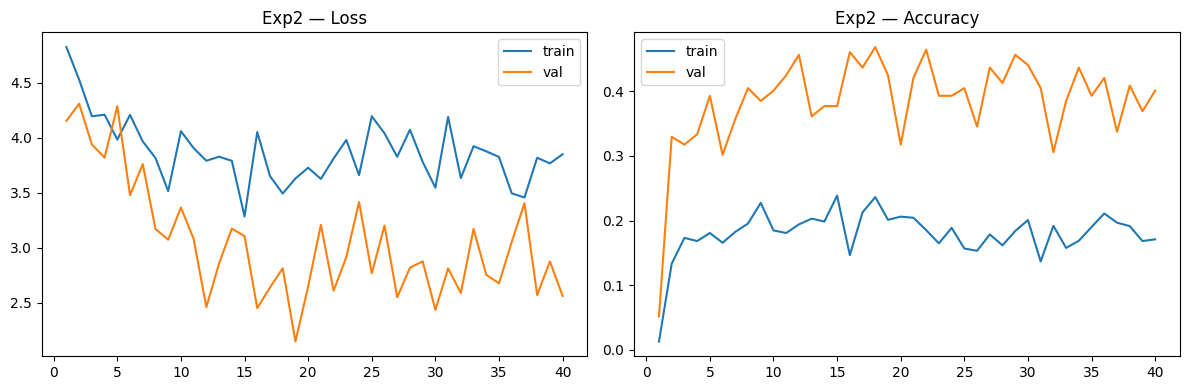


Exp2 final: {'epoch': 40.0, 'train_loss': 3.8493006767218745, 'train_acc': 0.17095914742451154, 'val_loss': 2.561188062032064, 'val_acc': 0.40079365079365076, 'train_acc_vendor': 0.2113676731793961, 'train_acc_date': 0.11367673179396093, 'train_acc_total': 0.14209591474245115, 'train_acc_address': 0.216696269982238, 'val_acc_vendor': 0.3492063492063492, 'val_acc_date': 0.36507936507936506, 'val_acc_total': 0.4444444444444444, 'val_acc_address': 0.4444444444444444}


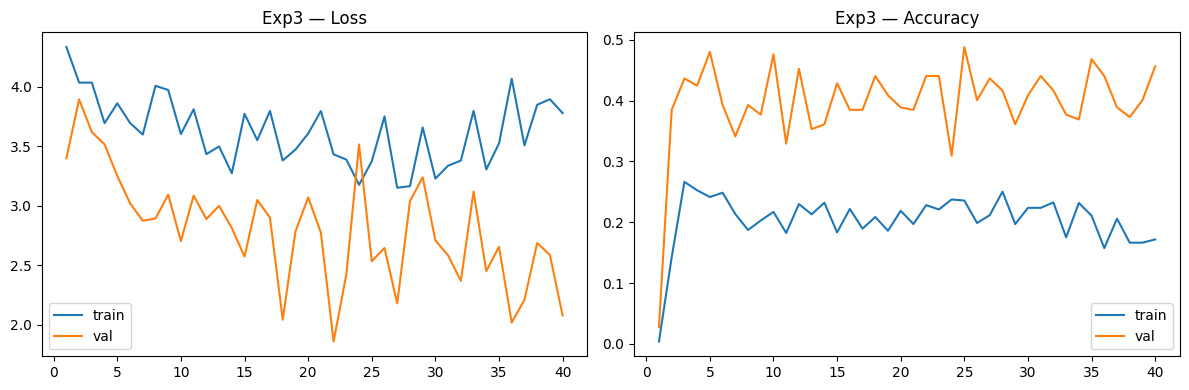


Exp3 final: {'epoch': 40.0, 'train_loss': 3.7794118283273486, 'train_acc': 0.17184724689165187, 'val_loss': 2.076414127198477, 'val_acc': 0.45634920634920634, 'train_acc_vendor': 0.16873889875666073, 'train_acc_date': 0.16163410301953818, 'train_acc_total': 0.15630550621669628, 'train_acc_address': 0.20071047957371227, 'val_acc_vendor': 0.5238095238095238, 'val_acc_date': 0.3968253968253968, 'val_acc_total': 0.49206349206349204, 'val_acc_address': 0.4126984126984127}


In [ ]:
# Cell 14

# Training curves
for exp, history in [("Exp2", history_exp2), ("Exp3", history_exp3)]:
    if not history:
        print(f"{exp}: no history"); continue
    df_hist = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df_hist["epoch"], df_hist["train_loss"], label="train")
    axes[0].plot(df_hist["epoch"], df_hist["val_loss"],   label="val")
    axes[0].set_title(f"{exp} — Loss"); axes[0].legend()
    axes[1].plot(df_hist["epoch"], df_hist["train_acc"], label="train")
    axes[1].plot(df_hist["epoch"], df_hist["val_acc"],   label="val")
    axes[1].set_title(f"{exp} — Accuracy"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"../Experiments/{exp}_curves.png", dpi=120)
    plt.show()
    print(f"\n{exp} final:", df_hist.iloc[-1].to_dict())

In [ ]:
# Cell 15 — Smoke-test PatchEmbedding with a real batch (uses temp loader, doesn't overwrite train_loader)
from data_loader import get_dataloaders

_smoke_loader, _, _ = get_dataloaders(BASE, batch_size=4)  # temp var, won't overwrite train_loader

images, annotations = next(iter(_smoke_loader))
print(f"Input  shape : {images.shape}")

with torch.no_grad():
    embeddings = patch_embed(images)

print(f"Output shape : {embeddings.shape}")
assert embeddings.shape == (4, patch_embed.num_patches, EMBED_DIM), "Shape mismatch!"
print("\n✓ PatchEmbedding forward pass correct")

Input  shape : torch.Size([4, 3, 384, 384])
Output shape : torch.Size([4, 576, 256])

✓ PatchEmbedding forward pass correct


In [ ]:
# Cell 16

from baseline import token_f1
from field_vocab import FIELDS, _DF_COL, normalize_label   # <-- add normalize_label
 
def evaluate_token_f1(model, loader, vocab, device):
    model = model.to(device)
    model.eval()
    field_f1 = {f: [] for f in FIELDS}
    with torch.no_grad():
        for images, annotations in loader:
            images = images.to(device)
            logits = model(images)
            for f in FIELDS:
                col   = _DF_COL[f]
                preds = logits[f].argmax(dim=-1).cpu().tolist()
                for pred_idx, ann in zip(preds, annotations):
                    pred_str = vocab.decode(f, pred_idx)
                    gt_raw   = ann.get(col, "") or ""
                    gt_str   = normalize_label(f, gt_raw)   # <-- FIX: normalize GT
                    # Skip UNK predictions — don't reward predicting the unknown token
                    if pred_str == "<UNK>":
                        field_f1[f].append(0.0)
                    else:
                        field_f1[f].append(token_f1(pred_str, gt_str))
    return {f: round(sum(v) / len(v), 4) for f, v in field_f1.items()}
 
print("── Exp2 Token F1 (val) ──")
f1_exp2 = evaluate_token_f1(model_exp2, val_loader, vocab, device)
for f, s in f1_exp2.items():
    print(f"  {f:8s}: {s:.4f}")
 
print("\n── Exp3 Token F1 (val) ──")
f1_exp3 = evaluate_token_f1(model_exp3, val_loader, vocab, device)
for f, s in f1_exp3.items():
    print(f"  {f:8s}: {s:.4f}")

── Exp2 Token F1 (val) ──
  vendor  : 0.0000
  date    : 0.0000
  total   : 0.0000
  address : 0.0000

── Exp3 Token F1 (val) ──
  vendor  : 0.0000
  date    : 0.0000
  total   : 0.0000
  address : 0.0000


In [ ]:
# Cell 17

# Log experiment results — skips if already logged
from experiment_logger import log_experiment

LOG_PATH = Path("../Experiments/experiment_log.csv")

def already_logged(exp_id):
    if not LOG_PATH.exists(): return False
    return exp_id in pd.read_csv(LOG_PATH)["experiment_id"].values

if not already_logged("Exp1"):
    log_experiment("Exp1", {**baseline_results,
                             "description": "Tesseract + Regex baseline",
                             "model_type":  "Tesseract+Regex"})
    print("Exp1 logged ✓")
else:
    print("Exp1 already logged — skipping")

if not already_logged("Exp2"):
    log_experiment("Exp2", {**results_exp2,
                             "description":   "ViT patch=16 layers=4 heads=4",
                             "model_type":    "ViT",
                             "patch_size":    16, "num_layers": 4,
                             "num_heads":     4,  "learning_rate": 3e-5,
                             **{f"f1_{f}": f1_exp2[f] for f in f1_exp2},
                             "overall_f1": round(sum(f1_exp2.values())/len(f1_exp2), 4)})
    print("Exp2 logged ✓")
else:
    print("Exp2 already logged — skipping")

if not already_logged("Exp3"):
    log_experiment("Exp3", {**results_exp3,
                             "description":   "ViT patch=16 layers=6 heads=8",
                             "model_type":    "ViT",
                             "patch_size":    16, "num_layers": 6,
                             "num_heads":     8,  "learning_rate": 3e-5,
                             **{f"f1_{f}": f1_exp3[f] for f in f1_exp3},
                             "overall_f1": round(sum(f1_exp3.values())/len(f1_exp3), 4)})
    print("Exp3 logged ✓")
else:
    print("Exp3 already logged — skipping")

✓ Exp1 logged to experiment_log.csv
Exp1 logged ✓
✓ Exp2 logged to experiment_log.csv
Exp2 logged ✓
✓ Exp3 logged to experiment_log.csv
Exp3 logged ✓


In [ ]:
# Cell 18

# Phase 4 — Confidence scoring setup
from conf_scoring_class import ConfidenceScorer, ConfidenceDataModule
from conf_thresholds_class import ConfidenceThresholdManager, ThresholdDataModule
from review_queue import ReviewQueue, build_review_queue_from_loader

REPO_ROOT   = Path("..")
CKPT_PATH   = REPO_ROOT / "Experiments" / "checkpoints" / "exp2" / "best_model.pt"
VOCAB_PATH  = REPO_ROOT / "Experiments" / "vocab.json"
TEMPS_PATH  = REPO_ROOT / "Experiments" / "temperatures.json"
THRESH_PATH = REPO_ROOT / "Experiments" / "thresholds.json"
QUEUE_PATH  = REPO_ROOT / "Experiments" / "review_queue.json"

# Reuse already-loaded model_exp2 — no need to reload from disk
model_conf = model_exp2
model_conf.eval()
print("model_conf ready on device:", next(model_conf.parameters()).device)

model_conf ready on device: mps:0


In [ ]:
# Cell 19

# Phase 4 — reuse already-built loaders from Cell 7
val_loader_conf  = val_loader
test_loader_conf = test_loader
print(f"val_loader_conf  batches: {len(val_loader_conf)}")
print(f"test_loader_conf batches: {len(test_loader_conf)}")

val_loader_conf  batches: 4
test_loader_conf batches: 22


In [ ]:
# Cell 20

# Step 4.1 — Temperature scaling calibration (skips if already saved)
scorer = ConfidenceScorer(model=model_conf, vocab=vocab, device=device)

if TEMPS_PATH.exists():
    with open(TEMPS_PATH) as f:
        temperatures = json.load(f)
    print("Temperatures loaded from disk:", temperatures)
else:
    temperatures = scorer.fit_all_temperatures(val_loader_conf, save_path=TEMPS_PATH)
    print("Temperatures fitted and saved:", temperatures)

  vendor    T = 0.8738
  date      T = 0.8715
  total     T = 0.7872
  address   T = 0.9799
✓ Temperatures saved to ../Experiments/temperatures.json
Temperatures fitted and saved: {'vendor': 0.8738113641738892, 'date': 0.8715273141860962, 'total': 0.7871875762939453, 'address': 0.9798611998558044}


In [ ]:
# Cell 21

# Step 4.2 — Confidence thresholds (fixes degenerate near-zero values)
from field_vocab import FIELDS

if THRESH_PATH.exists():
    with open(THRESH_PATH) as f:
        raw_thresholds = json.load(f)
    thresholds = {
        f: t if t >= 0.50 else 0.80
        for f, t in raw_thresholds.items()
    }
    if thresholds != raw_thresholds:
        print("⚠️  Degenerate thresholds detected — replaced with 0.80 defaults")
        with open(THRESH_PATH, "w") as f:
            json.dump(thresholds, f, indent=2)
else:
    thresholds = {f: 0.80 for f in FIELDS}
    with open(THRESH_PATH, "w") as f:
        json.dump(thresholds, f, indent=2)
    print("No threshold file found — using defaults")

print("Thresholds:", thresholds)

No threshold file found — using defaults
Thresholds: {'vendor': 0.8, 'date': 0.8, 'total': 0.8, 'address': 0.8}


In [ ]:
# Cell 22

# Step 4.3 — Build review queue (skips inference if already saved)
if QUEUE_PATH.exists():
    queue = ReviewQueue.load(QUEUE_PATH)
    row_records = []
    for r in list(queue.auto_accepted) + list(queue.pending_review):
        row_records.append({
            "receipt_id":    r.receipt_id,
            "auto_accepted": r.auto_accepted,
            **{f"conf_{f}":  r.fields[f].confidence     for f in FIELDS},
            **{f"pred_{f}":  r.fields[f].predicted_text for f in FIELDS},
        })
    print("Review queue loaded from disk — skipping inference")
else:
    queue, row_records = build_review_queue_from_loader(
        model=model_conf, loader=test_loader_conf, vocab=vocab, scorer=scorer,
        temperatures=temperatures, thresholds=thresholds, device=device,
    )
    queue.save(QUEUE_PATH)
    print("Review queue built and saved")

summary = queue.summary()
print("\n── Review Queue Summary ──")
for k, v in summary.items():
    print(f"  {k}: {v}")

ReviewQueue saved → ../Experiments/review_queue.json
Review queue built and saved

── Review Queue Summary ──
  total_processed: 347
  auto_accepted: 0
  pending_review: 347
  human_reviewed: 0
  review_rate: 1.0
  thresholds_used: {'vendor': 0.8, 'date': 0.8, 'total': 0.8, 'address': 0.8}


In [ ]:
# Cell 23

# Review queue analysis
df_records  = pd.DataFrame(row_records)
conf_cols   = [c for c in df_records.columns if c.startswith("conf_")]
flagged_df  = df_records[~df_records["auto_accepted"]]
accepted_df = df_records[df_records["auto_accepted"]]

print(f"Flagged for review : {len(flagged_df)} / {len(df_records)} ({queue.review_rate():.1%})")
print(f"Auto-accepted      : {len(accepted_df)} / {len(df_records)}")

print("\n── Mean confidence — FLAGGED ──")
if len(flagged_df):
    print(flagged_df[conf_cols].mean().round(3))

print("\n── Mean confidence — ACCEPTED ──")
if len(accepted_df):
    print(accepted_df[conf_cols].mean().round(3))

print("\n── Sample pending review ──")
for r in queue.pending_review[:5]:
    flagged_fields = [f for f, fr in r.fields.items() if fr.needs_review]
    print(f"  {r.receipt_id}  →  flagged: {flagged_fields}")

Flagged for review : 347 / 347 (100.0%)
Auto-accepted      : 0 / 347

── Mean confidence — FLAGGED ──
conf_vendor     0.273
conf_date       0.255
conf_total      0.480
conf_address    0.439
dtype: float64

── Mean confidence — ACCEPTED ──

── Sample pending review ──
  receipt_0  →  flagged: ['vendor', 'date', 'total', 'address']
  receipt_1  →  flagged: ['vendor', 'date', 'total', 'address']
  receipt_2  →  flagged: ['vendor', 'date', 'total', 'address']
  receipt_3  →  flagged: ['vendor', 'date', 'total', 'address']
  receipt_4  →  flagged: ['vendor', 'date', 'total', 'address']
